
##### Sets & Parameters

- $I = \{1,\dots,N\}$: set of robots
- $W$: width of the area
- $H$: height of the area

##### Decision Variables

- $x_i \in \mathbb{Z}$: x-coordinate of robot $i$
- $y_i \in \mathbb{Z}$: y-coordinate of robot $i$
- $D \in \mathbb{Z}$: minimum squared distance between any two robots


##### Complete Model

$$
\boxed{
\begin{aligned}
\max \quad & D \\[2mm]
\text{s.t.} \quad
& 0 \le x_i \le W && \forall i \in I \\[1mm]
& 0 \le y_i \le H && \forall i \in I \\[1mm]
& D \le (x_i - x_j)^2 + (y_i - y_j)^2 && \forall i,j \in I, \; i < j \\[1mm]
& x_i < x_{i+1} \lor (x_i = x_{i+1} \land y_i \le y_{i+1}) && \forall i = 1,\dots,N-1 \\[1mm]
& x_i, y_i \in \mathbb{Z} && \forall i \in I
\end{aligned}
}
$$

In [8]:
from ortools.sat.python import cp_model

In [126]:
I = list(range(1,16))
Width = 12
Height = 16

In [127]:
model = cp_model.CpModel()

In [128]:
x = {i: model.NewIntVar(0, Width, f"x[{i}]") for i in I}
y = {i: model.NewIntVar(0, Height, f"y[{i}]") for i in I}

In [129]:
dij = {}
D = model.NewIntVar(0, Width*Width + Height*Height, "D")
for i in I:
    for j in I:
        if i<j:
            dx = model.NewIntVar(-Width, Width, f"dx[{i},{j}]")
            dy = model.NewIntVar(-Height, Height, f"dy[{i},{j}]")
    
            dx2 = model.NewIntVar(0, Width*Width, f"dx2[{i},{j}]")
            dy2 = model.NewIntVar(0, Height*Height, f"dy2[{i},{j}]")


            dij[i,j] = dx2+dy2
            model.Add(dx == x[i] - x[j])
            model.Add(dy == y[i] - y[j])

            model.AddMultiplicationEquality(dx2, [dx, dx])
            model.AddMultiplicationEquality(dy2, [dy, dy])
    
            model.Add(D <= dx2+dy2)


In [130]:
for i in I[:-1]:
    diffx = model.NewBoolVar(f"diffx[{i},{i+1}]")
    equalx = model.NewBoolVar(f"equalx[{i},{i+1}]")

    model.AddBoolOr([diffx, equalx])

    model.Add(x[i] < x[i+1]).OnlyEnforceIf(diffx)

    model.Add(x[i] == x[i+1]).OnlyEnforceIf(equalx)
    model.Add(y[i] <=y[i+1]).OnlyEnforceIf(equalx)

In [131]:
model.Maximize(D)

In [134]:
solver = cp_model.CpSolver()
solver.parameters.max_time_in_seconds = 20
status = solver.Solve(model)

print(status)
# for i in I:
#     print(i, x[i], y[i], solver.Value(x[i]), solver.Value(y[i]))

CpSolverStatus.OPTIMAL


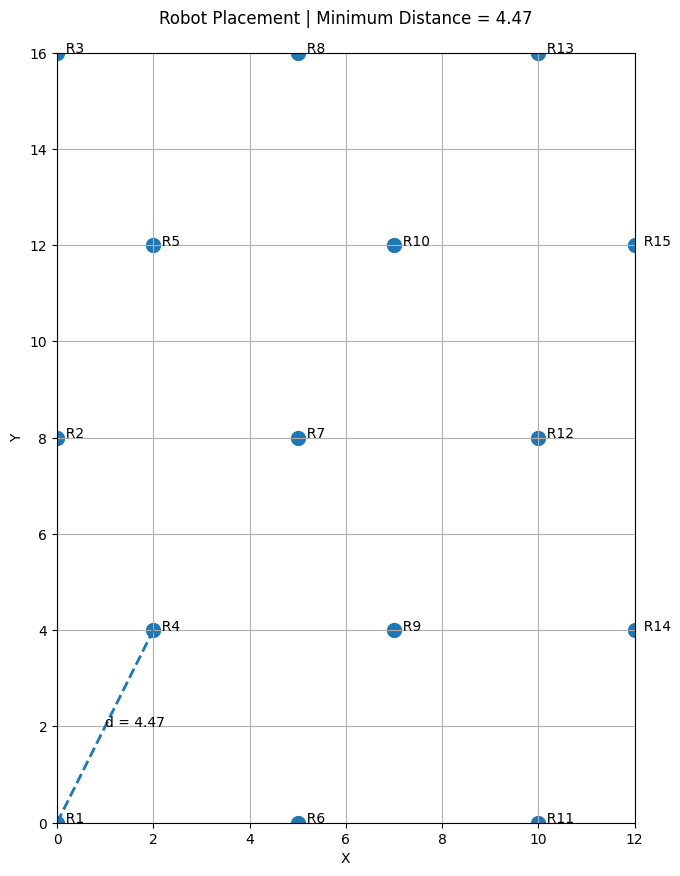

In [135]:
# Directly copy-pasted this part from AI
import matplotlib.pyplot as plt
import math

if status == cp_model.OPTIMAL or status == cp_model.FEASIBLE:
    X = {i: solver.Value(x[i]) for i in I}
    Y = {i: solver.Value(y[i]) for i in I}
    min_dist = float("inf")
    closest_pair = None
    for i in I:
        for j in I:
            if i < j:
                dist = math.sqrt( (X[i] - X[j])**2 + (Y[i] - Y[j])**2 )
                if dist < min_dist:
                    min_dist = dist
                    closest_pair = (i, j)

    ratio = Width / Height
    plt.figure(figsize=(10 * ratio, 10))
    plt.scatter( list(X.values()), list(Y.values()), s=100 )

    for i in I:
        plt.text( X[i], Y[i], f"  R{i}", fontsize=10 )

    i, j = closest_pair
    plt.plot( [X[i], X[j]], [Y[i], Y[j]], linestyle="--", linewidth=2 )
    mid_x = (X[i] + X[j]) / 2
    mid_y = (Y[i] + Y[j]) / 2
    plt.text( mid_x, mid_y, f"d = {min_dist:.2f}", fontsize=10 )
    plt.xlim(0, Width)
    plt.ylim(0, Height)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title( f"Robot Placement | Minimum Distance = {min_dist:.2f}\n" )
    plt.grid(True)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.show()